In [1]:
#cspell:words backtest DEMA
import config as cfg
import yfinance as yf
import pandas as pd
import numpy as np
import indicators as ind
import data
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


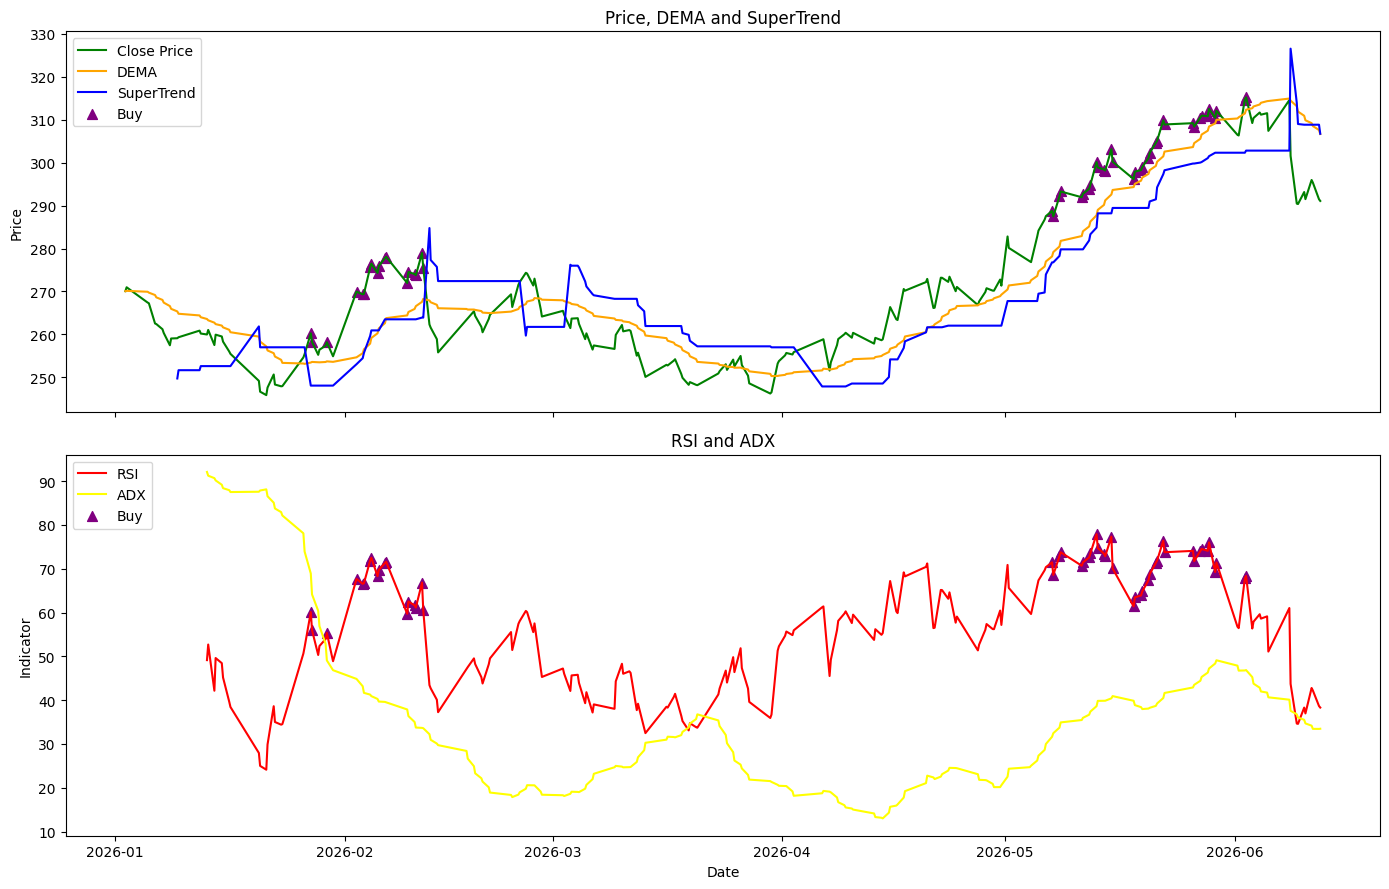

In [21]:
import importlib

#cspell:words backtest DEMA xlabel ylabel sharex figsize
importlib.reload(cfg)
importlib.reload(ind)
importlib.reload(data)
df = data.df.dropna()

indicator_df = pd.DataFrame({
    'ATR': ind.ATR(df).calculate(),
    'SuperTrend': ind.SuperTrend(df).calculate(),
    'ADX': ind.ADX(df).calculate(),
    'RSI': ind.RSI(df).calculate(),
    'DEMA': ind.DEMA(df).calculate(),
}, index=df.index).interpolate(method='time', limit_area='inside')

mask = (
    (df["Close"] > indicator_df["DEMA"]) &
    (indicator_df["RSI"] > 55) &
    (indicator_df["ADX"] > 30) &
    (indicator_df["ATR"] > 0) &
    (indicator_df["SuperTrend"] < df["Close"])
).fillna(False)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 9))

ax1.plot(df.index, df["Close"], label="Close Price", color="green")
ax1.plot(indicator_df.index, indicator_df["DEMA"], label="DEMA", color="orange")
ax1.plot(indicator_df.index, indicator_df["SuperTrend"], label="SuperTrend", color="blue")
ax1.scatter(df.index[mask], df.loc[mask, "Close"], marker="^", color="purple", s=50, label="Buy")
ax1.set_title("Price, DEMA and SuperTrend")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")

ax2.plot(indicator_df.index, indicator_df["RSI"], label="RSI", color="red")
ax2.plot(indicator_df.index, indicator_df["ADX"], label="ADX", color="yellow")
ax2.scatter(df.index[mask], indicator_df.loc[mask, "RSI"], marker="^", color="purple", s=50, label="Buy")
ax2.set_title("RSI and ADX")
ax2.set_ylabel("Indicator")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()